In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import requests
file_url = "https://storage.googleapis.com/ads-dataset/subfolder-10.zip"

r = requests.get(file_url, stream = True)

with open("/content/gdrive/My Drive/subfolder-10.zip", "wb") as file:
	for block in r.iter_content(chunk_size = 1024):
		if block:
			file.write(block)

In [ ]:
!unzip "/content/gdrive/My Drive/subfolder-10.zip" -d "/content/gdrive/My Drive/subfolder-10"

Streaming output truncated to the last 5000 lines.
  inflating: /content/gdrive/My Drive/subfolder-10/10/173349.png  
  inflating: /content/gdrive/My Drive/subfolder-10/10/173350.png  
  inflating: /content/gdrive/My Drive/subfolder-10/10/173351.png  
  inflating: /content/gdrive/My Drive/subfolder-10/10/173352.png  
  inflating: /content/gdrive/My Drive/subfolder-10/10/173353.png  
  inflating: /content/gdrive/My Drive/subfolder-10/10/173354.png  
  inflating: /content/gdrive/My Drive/subfolder-10/10/173355.png  
  inflating: /content/gdrive/My Drive/subfolder-10/10/173356.png  
  inflating: /content/gdrive/My Drive/subfolder-10/10/173357.png  
  inflating: /content/gdrive/My Drive/subfolder-10/10/173358.png  
  inflating: /content/gdrive/My Drive/subfolder-10/10/173359.png  
  inflating: /content/gdrive/My Drive/subfolder-10/10/173360.png  
  inflating: /content/gdrive/My Drive/subfolder-10/10/173361.png  
  inflating: /content/gdrive/My Drive/subfolder-10/10/173362.png  
  inflating

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Step 1: Data Preparation

data_dir = "/content/gdrive/My Drive/subfolder-10"

transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize images to 64x64
    transforms.ToTensor(),       # Convert images to tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=100, shuffle=True)

# Step 2: Define the Diffusion Model (UNet)

class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        self.middle = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 3, kernel_size=3, stride=1, padding=1)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.middle(x)
        x = self.decoder(x)
        return x

# Step 3: Training Loop

def train_diffusion_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.0002)
    criterion = nn.MSELoss()

    epochs = 10
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for images, _ in dataloader:
            images = images.to(device)

            # Simulate noise and denoise process (basic diffusion)
            noise = torch.randn_like(images).to(device)
            noisy_images = images + noise

            optimizer.zero_grad()
            denoised_images = model(noisy_images)
            loss = criterion(denoised_images, images)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {epoch_loss / len(dataloader):.4f}")

    # Save model
    torch.save(model.state_dict(), "diffusion_model.pth")

# Step 4: Run the Training
if __name__ == "__main__":
    train_diffusion_model()


KeyboardInterrupt: 

In [ ]:
# Define a random input tensor
random_input = torch.randn(1, 3, 64, 64)

# Instantiate the UNet model
model = UNet()

# Print model architecture
print(model)

# Get output for the random input
output = model(random_input)

# Print the shape of the output
print("Output shape:", output.shape)


UNet(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (middle): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)
Output shape: torch.Size([1, 3, 64, 64])


<ipython-input-9-10bc77906d98>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("diffusion_model.pth", map_location=device))


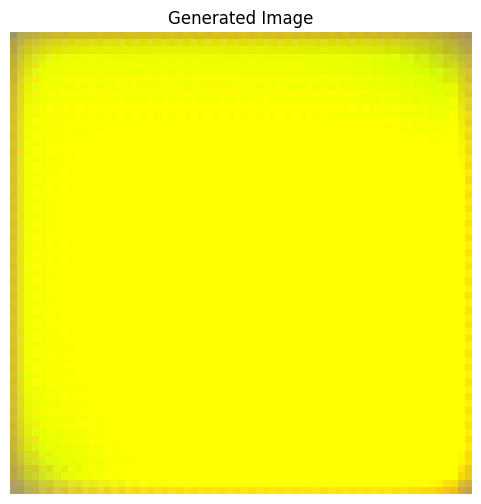

In [ ]:
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import ToPILImage

# Load the trained UNet model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
model.load_state_dict(torch.load("diffusion_model.pth", map_location=device))
model.eval()

# Diffusion parameters
timesteps = 1000  # Number of diffusion steps
beta = torch.linspace(0.0001, 0.02, timesteps).to(device)  # Noise schedule
alpha = 1.0 - beta
alpha_cum = torch.cumprod(alpha, dim=0)  # Cumulative product of alpha

# Reverse diffusion process
@torch.no_grad()
def generate_image(model, timesteps, img_size=(3, 64, 64)):
    noise = torch.randn(1, *img_size).to(device)  # Start with pure noise
    for t in reversed(range(timesteps)):
        # Calculate the predicted denoised image
        predicted_denoise = model(noise)

        # Reverse diffusion formula
        if t > 0:
            z = torch.randn_like(noise)  # Sample noise for stochasticity
            noise = (
                torch.sqrt(alpha[t]) * predicted_denoise +
                torch.sqrt(beta[t]) * z
            )
        else:
            noise = predicted_denoise  # Final step (deterministic)

    return noise.squeeze(0)  # Return the generated image

# Generate an image
generated_image = generate_image(model, timesteps)

# Convert tensor to image
generated_image = (generated_image.clamp(-1, 1) + 1) / 2  # Rescale to [0, 1]
generated_image = generated_image.permute(1, 2, 0).cpu().numpy()  # Convert to HWC format

# Plot and display the generated image
plt.figure(figsize=(6, 6))
plt.imshow(generated_image)
plt.axis('off')  # Hide axes for better display
plt.title("Generated Image")
plt.show()


In [ ]:
!pip install diffusers

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

...

unet/config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

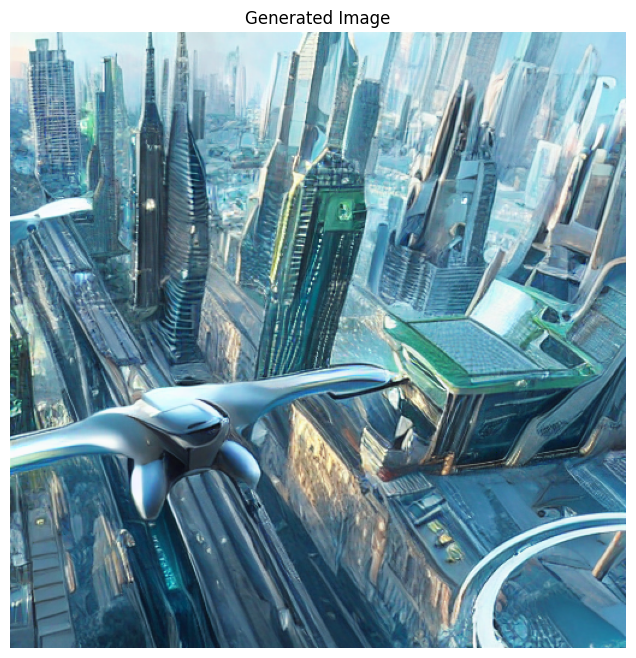

In [ ]:
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt

# Step 1: Load the Pre-trained Stable Diffusion Model
def load_model():
    # Load the Stable Diffusion pipeline (you can specify another pre-trained model if needed)
    model_name = "runwayml/stable-diffusion-v1-5"  # Replace with your desired model
    pipe = StableDiffusionPipeline.from_pretrained(model_name)
    pipe = pipe.to("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
    return pipe

# Step 2: Generate an Image
def generate_image(pipe, prompt="A beautiful landscape with mountains and a river", seed=42):
    # Set the random seed for reproducibility
    generator = torch.manual_seed(seed)

    # Generate an image based on the prompt
    output = pipe(prompt, num_inference_steps=50, generator=generator)
    image = output.images[0]
    return image

# Step 3: Visualize the Image
def visualize_image(image):
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Generated Image")
    plt.show()

# Main
if __name__ == "__main__":
    # Load the model
    pipeline = load_model()

    # Generate and visualize the image
    generated_image = generate_image(pipeline, prompt="A futuristic cityscape with flying cars")
    visualize_image(generated_image)


In [ ]:
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

# Step 1: Load the Pre-trained Stable Diffusion Model
def load_pipeline():
    model_name = "runwayml/stable-diffusion-v1-5"
    pipeline = StableDiffusionPipeline.from_pretrained(model_name)
    pipeline = pipeline.to("cuda" if torch.cuda.is_available() else "cpu")
    return pipeline

# Step 2: Prepare Custom Dataset (Fine-tuning)
def prepare_dataloader(data_dir, batch_size=8):
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
    ])

    # Modify: Add a 4th channel (example: add a dummy channel, e.g., zero)
    def add_dummy_channel(image):
        # Convert to RGBA by adding a dummy channel (alpha channel or just zeros)
        image = transforms.ToPILImage()(image)  # Convert to PIL to manipulate channels
        image = image.convert("RGBA")  # Convert to RGBA format
        image = transforms.ToTensor()(image)  # Convert back to tensor
        return image

    dataset = datasets.ImageFolder(root=data_dir, transform=transform)

    # Modify dataset to include the extra channel
    class ModifiedDataset(torch.utils.data.Dataset):
        def __init__(self, dataset):
            self.dataset = dataset

        def __len__(self):
            return len(self.dataset)

        def __getitem__(self, idx):
            image, label = self.dataset[idx]
            image = add_dummy_channel(image)  # Add the dummy channel here
            return image, label

    modified_dataset = ModifiedDataset(dataset)
    dataloader = DataLoader(modified_dataset, batch_size=batch_size, shuffle=True)
    return dataloader


# Step 3: Fine-tuning (Optional Step, only if you want to fine-tune the model)
def fine_tune(pipeline, dataloader, epochs=5, lr=5e-5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    unet = pipeline.unet.to(device)  # Extract the UNet model
    optimizer = optim.AdamW(unet.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Assuming you have a text encoder or you can use dummy embeddings
    # We will create dummy encoder hidden states for the example
    batch_size = 8  # Define batch size

    for epoch in range(epochs):
        epoch_loss = 0.0
        for batch_idx, (images, _) in enumerate(dataloader):
            images = images.to(device)
            noise = torch.randn_like(images).to(device)

            # Generate noisy images (a simple example for fine-tuning)
            noisy_images = images + noise

            # Generate random timesteps (for the diffusion process)
            timestep = torch.randint(0, 1000, (images.size(0),), device=device)  # Random timestep
            timestep = timestep.float()  # Convert to float for compatibility

            # Dummy encoder hidden states (usually this is from a text encoder)
            encoder_hidden_states = torch.randn(images.size(0), 77, 768, device=device)  # Random tensor, replace with actual text embeddings

            # Forward pass: Predict the noise
            noise_pred = unet(noisy_images, timestep=timestep, encoder_hidden_states=encoder_hidden_states).sample

            # Compute loss
            loss = criterion(noise_pred, noise)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {epoch_loss / len(dataloader):.4f}")

# Step 4: Generate and Visualize an Image
def generate_image(pipe, prompt="A custom image generated by fine-tuned model", seed=42):
    generator = torch.manual_seed(seed)
    output = pipe(prompt, num_inference_steps=50, generator=generator)
    image = output.images[0]
    return image

def visualize_image(image):
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Generated Image")
    plt.show()

# Main Execution
if __name__ == "__main__":
    # Directory containing your custom dataset for fine-tuning (replace with your own path)
    data_dir = "/content/gdrive/My Drive/subfolder-10"
    batch_size = 100
    epochs = 5
    learning_rate = 5e-5

    # Step 1: Load the pipeline
    pipeline = load_pipeline()

    # Step 2: Prepare the dataloader for fine-tuning
    dataloader = prepare_dataloader(data_dir, batch_size)

    # Step 3: Fine-tune the model (Optional)
    fine_tune(pipeline, dataloader, epochs, learning_rate)

    # Step 4: Generate and visualize an image
    generated_image = generate_image(pipeline, prompt="A futuristic cityscape with flying cars")
    visualize_image(generated_image)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 500.00 MiB. GPU 0 has a total capacity of 14.75 GiB of which 311.06 MiB is free. Process 583336 has 14.44 GiB memory in use. Of the allocated memory 12.24 GiB is allocated by PyTorch, and 2.08 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)